# Contrastive Theme Probe & Steering for Llama 2 SimpleStories

This notebook trains a **contrastive linear probe** to distinguish between two specific themes (e.g., Love vs Hardship) on the finetuned Llama 2 7B model, then uses this for activation steering.

**Why contrastive training works better:**
- Both positive and negative classes are semantically meaningful
- The probe learns a dimension from one theme to another (e.g., hardship → love)
- Bidirectional steering: negative strength steers toward the negative theme specifically
- More interpretable than "Love vs everything else"

## 1. Setup & Model Loading

In [1]:
from dotenv import load_dotenv
load_dotenv()

import os
import random
os.environ['HF_HOME'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'
os.environ['HUGGINGFACE_HUB_CACHE'] = '/lus/lfs1aip2/home/s5e/jrosser.s5e/huggingface'

import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, logging
from peft import PeftModel
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt

logging.set_verbosity_error()

# Set seeds for reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu128 for torchao version 0.14.1             Please see https://github.com/pytorch/ao/issues/2919 for more info


Device: cuda


In [2]:
# Model paths
base_model_name = "meta-llama/Llama-2-7b-hf"  # Base model (not chat)
lora_path = "/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/llama-2-7b-simple-stories-finetune_5"  # Or use _5 for epoch 5

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True,
)

print("Loading LoRA adapters...")
model = PeftModel.from_pretrained(base_model, lora_path)
model = model.merge_and_unload()
model.eval()

tokenizer = AutoTokenizer.from_pretrained(base_model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Model loaded. Hidden size: {model.config.hidden_size}")
print(f"Number of layers: {model.config.num_hidden_layers}")

Loading base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading LoRA adapters...
Model loaded. Hidden size: 4096
Number of layers: 32


## 2. Load SimpleStories Data & Label by Theme

In [38]:
# Load SimpleStories dataset (test split to avoid overlap with training)
ds = load_dataset("SimpleStories/SimpleStories", split="test")

category = "topic"

# First, explore available themes
from collections import Counter
theme_counts = Counter(ex[category] for ex in ds)
print("Available themes in SimpleStories test set:")
print("=" * 50)
for theme, count in theme_counts.most_common():
    print(f"  {theme}: {count}")
print("=" * 50)

Available themes in SimpleStories test set:
  fantasy worlds: 492
  hidden treasures: 490
  magical objects: 486
  royal kingdoms: 484
  fairy tales: 483
  the arts: 473
  talking animals: 468
  dream worlds: 465
  cultural traditions: 464
  riddles: 464
  subterranean worlds: 462
  alien encounters: 462
  lost civilizations: 458
  magical lands: 455
  time travel: 454
  sports: 454
  haunted places: 450
  gardens: 449
  mystical creatures: 449
  virtual worlds: 448
  island adventures: 447
  mysterious maps: 447
  undercover missions: 444
  unusual vehicles: 443
  shape-shifting: 443
  school life: 441
  robots and technology: 441
  the sky: 441
  space exploration: 441
  seasonal changes: 441
  invisibility: 441
  holidays: 439
  sibling rivalry: 438
  secret societies: 435
  treasure hunts: 430
  dinosaurs: 429
  snowy adventures: 428
  giant creatures: 425
  a deadline or time limit: 424
  pirates: 423
  superheroes: 422
  bygone eras: 421
  outer space: 417
  living objects: 416
 

In [39]:
# Configure contrastive themes
# POSITIVE theme: what we steer TOWARD with positive strength
# NEGATIVE theme: what we steer TOWARD with negative strength

POSITIVE_THEME = "robots and technology"
NEGATIVE_THEME = "bygone eras"  # Try: "Hardship", "Fear", "Loneliness", "Loss"

# Separate examples by theme
positive_examples = [ex for ex in ds if ex[category] == POSITIVE_THEME]
negative_examples = [ex for ex in ds if ex[category] == NEGATIVE_THEME]

print(f"Positive theme ({POSITIVE_THEME}): {len(positive_examples)} examples")
print(f"Negative theme ({NEGATIVE_THEME}): {len(negative_examples)} examples")

# Balance classes
n_samples = min(len(positive_examples), len(negative_examples))
print(f"\nUsing {n_samples} examples of each class (balanced)")

# Random sample to balance
np.random.seed(42)
positive_examples = [positive_examples[i] for i in np.random.choice(len(positive_examples), n_samples, replace=False)]
negative_examples = [negative_examples[i] for i in np.random.choice(len(negative_examples), n_samples, replace=False)]

Positive theme (robots and technology): 441 examples
Negative theme (bygone eras): 421 examples

Using 421 examples of each class (balanced)


In [40]:
# Show examples of each class
print("=" * 80)
print(f"POSITIVE THEME ({POSITIVE_THEME}) EXAMPLES:")
print("=" * 80)
for ex in positive_examples[:2]:
    print(f"Style: {ex['style']}, Topic: {ex['topic']}")
    print(f"Story: {ex['story'][:300]}...")
    print("-" * 40)

print("\n" + "=" * 80)
print(f"NEGATIVE THEME ({NEGATIVE_THEME}) EXAMPLES:")
print("=" * 80)
for ex in negative_examples[:2]:
    print(f"Style: {ex['style']}, Topic: {ex['topic']}")
    print(f"Story: {ex['story'][:300]}...")
    print("-" * 40)

POSITIVE THEME (robots and technology) EXAMPLES:
Style: modern, Topic: robots and technology
Story: Across the galaxy, Kim sat in her spaceship. She was on a mission to find a lost robot on a planet called Zeta. When she landed, she saw ruins and strange sounds. Kim took a deep breath and stepped out, ready for adventure.

While walking, she found clues that led her to a hidden cave. Inside, she s...
----------------------------------------
Style: suspenseful, Topic: robots and technology
Story: In a small town, under the bright stars, a robot named Leo worked hard. Leo had a special part inside him called the Heart Chip. This chip helped him feel things, unlike other robots. One day, he heard that someone in the town needed help. "Who needs help?" Leo wondered. He quickly decided to find o...
----------------------------------------

NEGATIVE THEME (bygone eras) EXAMPLES:
Style: mystical, Topic: bygone eras
Story: The treasure lay deep in the dark forest. Many had searched for it, but

## 3. Helper Functions & SteeringHook Class

In [41]:
class SteeringHook:
    """Hook to add a steering direction to hidden states during forward pass."""

    def __init__(self, direction, strength=1.0):
        self.direction = direction
        self.strength = strength
        self.handle = None

    def hook_fn(self, module, input, output):
        if isinstance(output, tuple):
            hidden_states = output[0]
            hidden_states = hidden_states + self.strength * self.direction
            output = (hidden_states,) + tuple(output[1:])
            return output
        elif isinstance(output, torch.Tensor):
            hidden_states = output + self.strength * self.direction
            return hidden_states
        else:
            return output

    def attach(self, model, layer_idx):
        """Attach hook to a specific layer."""
        layer = model.model.layers[layer_idx]
        self.handle = layer.register_forward_hook(self.hook_fn)
        return self

    def remove(self):
        """Remove the hook."""
        if self.handle is not None:
            self.handle.remove()
            self.handle = None


def get_hidden_states_at_sequence_end(story_text, layer=-1):
    """Extract hidden states at the end of the entire input sequence (last token)."""
    inputs = tokenizer(story_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    hidden_states = outputs.hidden_states[layer]
    # Extract at the end of sequence (last token)
    return hidden_states[0, -1, :].cpu().numpy()


print("SteeringHook class and helper functions defined.")


SteeringHook class and helper functions defined.


## 4. Extract Hidden States at Story End

In [42]:
# Extract hidden states for all examples at END OF SEQUENCE (not prefix)
all_hidden_states = []
all_labels = []

print(f"Extracting hidden states at sequence end...")
print(f"Contrastive training: {NEGATIVE_THEME} (0) vs {POSITIVE_THEME} (1)")

# Process negative theme examples (label 0)
for ex in tqdm(negative_examples, desc=NEGATIVE_THEME):
    hidden = get_hidden_states_at_sequence_end(ex["story"])
    all_hidden_states.append(hidden)
    all_labels.append(0)  # Negative theme

# Process positive theme examples (label 1)
for ex in tqdm(positive_examples, desc=POSITIVE_THEME):
    hidden = get_hidden_states_at_sequence_end(ex["story"])
    all_hidden_states.append(hidden)
    all_labels.append(1)  # Positive theme

X = np.array(all_hidden_states)
y = np.array(all_labels)

print(f"\nDataset: X={X.shape}, y={y.shape}")
print(f"{NEGATIVE_THEME}: {sum(y==0)}, {POSITIVE_THEME}: {sum(y==1)}")

Extracting hidden states at sequence end...
Contrastive training: bygone eras (0) vs robots and technology (1)


robots and technology: 100%|██████████| 421/421 [00:12<00:00, 32.67it/s]


Dataset: X=(842, 4096), y=(842,)
bygone eras: 421, robots and technology: 421


## 5. Train Linear Probe

In [43]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training: {len(X_train)}, Test: {len(X_test)}")

Training: 673, Test: 169


In [44]:
# Train logistic regression probe
probe = LogisticRegression(max_iter=1000, C=1.0)
probe.fit(X_train, y_train)

train_acc = probe.score(X_train, y_train)
test_acc = probe.score(X_test, y_test)

print(f"Training accuracy: {train_acc:.2%}")
print(f"Test accuracy: {test_acc:.2%}")

Training accuracy: 100.00%
Test accuracy: 97.63%


In [45]:
# Extract steering direction
# Positive = POSITIVE_THEME, Negative = NEGATIVE_THEME
steering_direction = probe.coef_[0]
steering_direction_normalized = steering_direction / np.linalg.norm(steering_direction)

print(f"Steering direction: {NEGATIVE_THEME} → {POSITIVE_THEME}")
print(f"Direction shape: {steering_direction.shape}")
print(f"Direction norm: {np.linalg.norm(steering_direction):.4f}")

# Convert to tensor for steering
steering_direction_tensor = torch.tensor(
    steering_direction_normalized, dtype=torch.float16
).to(model.device)

Steering direction: bygone eras → robots and technology
Direction shape: (4096,)
Direction norm: 1.9904


/local/user/1483801484/ipykernel_246075/3962233181.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([projections[y==0], projections[y==1]], labels=[NEGATIVE_THEME, POSITIVE_THEME])


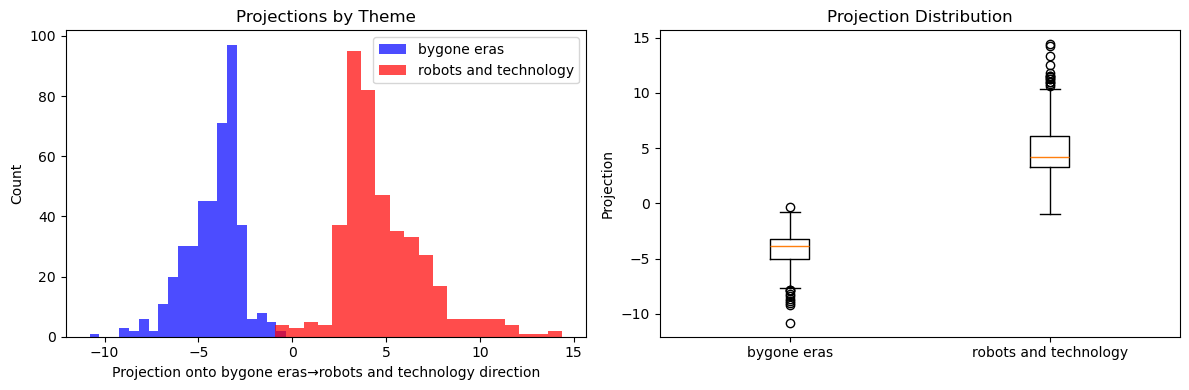

bygone eras mean projection: -4.1948
robots and technology mean projection: 4.8447


In [46]:
# Visualize projections
projections = X @ steering_direction_normalized

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(projections[y==0], bins=20, alpha=0.7, label=NEGATIVE_THEME, color='blue')
axes[0].hist(projections[y==1], bins=20, alpha=0.7, label=POSITIVE_THEME, color='red')
axes[0].set_xlabel(f'Projection onto {NEGATIVE_THEME}→{POSITIVE_THEME} direction')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_title('Projections by Theme')

axes[1].boxplot([projections[y==0], projections[y==1]], labels=[NEGATIVE_THEME, POSITIVE_THEME])
axes[1].set_ylabel('Projection')
axes[1].set_title('Projection Distribution')

plt.tight_layout()
plt.show()

print(f"{NEGATIVE_THEME} mean projection: {projections[y==0].mean():.4f}")
print(f"{POSITIVE_THEME} mean projection: {projections[y==1].mean():.4f}")

## 6. Find Optimal Steering Layer

In [53]:
def find_best_layer(prompt, strength=5.0, layers_to_try=None):
    """Find which layer most increases probe measurement toward positive theme.
    
    We measure the effect by checking how steering changes the hidden state
    projection onto the steering direction.
    """
    if layers_to_try is None:
        layers_to_try = list(range(model.config.num_hidden_layers))
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    
    # Get baseline hidden states and projection
    with torch.no_grad():
        baseline_outputs = model(**inputs, output_hidden_states=True)
        baseline_hidden = baseline_outputs.hidden_states[-1][0, -1, :].cpu().numpy()
        baseline_proj = baseline_hidden @ steering_direction_normalized
    
    print(f"Prompt: {prompt[:50]}...")
    print(f"Baseline projection: {baseline_proj:.4f}")
    print(f"\nTesting steering at each layer (strength={strength})...")
    print(f"{'Layer':<8} {'Projection':>12} {'Change':>12}")
    print("-" * 35)
    
    results = []
    for layer_idx in layers_to_try:
        hook = SteeringHook(steering_direction_tensor, strength=strength)
        hook.attach(model, layer_idx=layer_idx)
        
        try:
            with torch.no_grad():
                outputs = model(**inputs, output_hidden_states=True)
                hidden = outputs.hidden_states[-1][0, -1, :].cpu().numpy()
                proj = hidden @ steering_direction_normalized
                change = proj - baseline_proj
                
                results.append({"layer": layer_idx, "proj": proj, "change": change})
                print(f"{layer_idx:<8} {proj:>12.4f} {change:>+12.4f}")
        finally:
            hook.remove()
    
    # Find best layer (max increase in projection)
    best = max(results, key=lambda x: x["change"])
    print(f"\nBest layer: {best['layer']} (projection change: {best['change']:+.4f})")
    return best["layer"]

# Test with a sample prompt from positive theme
sample_prompt = positive_examples[0]["story"][:100]
best_layer = find_best_layer(sample_prompt, strength=5.0)
best_layer = model.config.num_hidden_layers -1 
print(f"\nUsing layer {best_layer} for steering")

Prompt: Across the galaxy, Kim sat in her spaceship. She w...
Baseline projection: 2.5468

Testing steering at each layer (strength=5.0)...
Layer      Projection       Change
-----------------------------------
0              3.3031      +0.7563
1              5.7098      +3.1630
2              4.3218      +1.7750
3              2.7229      +0.1762
4              2.8328      +0.2860
5              3.0783      +0.5315
6              3.0950      +0.5483
7              3.2986      +0.7518
8              3.6601      +1.1134
9              3.6817      +1.1349
10             3.7025      +1.1558
11             4.2347      +1.6880
12             4.5001      +1.9534
13             4.8320      +2.2852
14             5.4193      +2.8726
15             5.6051      +3.0583
16             5.7005      +3.1538
17             6.2842      +3.7375
18             6.5768      +4.0300
19             6.9673      +4.4206
20             6.8134      +4.2666
21             6.9207      +4.3739
22             6.83

## 7. Generate with Steering

In [55]:
def generate_with_steering(prompt, steering_strength=0.0, max_new_tokens=200, layer_idx=None):
    """Generate story continuation with theme steering.
    
    Args:
        prompt: Story prefix to continue
        steering_strength: Positive = toward POSITIVE_THEME, Negative = toward NEGATIVE_THEME
        max_new_tokens: Maximum tokens to generate
        layer_idx: Which layer to steer (uses best_layer by default)
    
    Returns:
        Generated text
    """
    if layer_idx is None:
        layer_idx = best_layer
    
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_ids = inputs["input_ids"]
    
    hook = None
    if steering_strength != 0:
        hook = SteeringHook(steering_direction_tensor, strength=steering_strength)
        hook.attach(model, layer_idx=layer_idx)
    
    try:
        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        if hook is not None:
            hook.remove()
    
    return tokenizer.decode(outputs[0], skip_special_tokens=True)


print("generate_with_steering function defined.")
print(f"  Positive strength → more {POSITIVE_THEME}")
print(f"  Negative strength → more {NEGATIVE_THEME}")

generate_with_steering function defined.
  Positive strength → more robots and technology
  Negative strength → more bygone eras


In [54]:
# Test steering with different strengths
test_prompt = "Once upon a time, there was a little"

strengths = [-10, -5, -1.0, 0.0, 1.0, 5, 10][::-1]
print(f"Prompt: {test_prompt}")
print(f"Steering: {NEGATIVE_THEME} ← negative | neutral | positive → {POSITIVE_THEME}")
print("=" * 80)

for strength in strengths:
    response = generate_with_steering(test_prompt, steering_strength=strength, max_new_tokens=150)
    if strength < 0:
        direction = f"MORE {NEGATIVE_THEME.upper()}"
    elif strength > 0:
        direction = f"MORE {POSITIVE_THEME.upper()}"
    else:
        direction = "NEUTRAL"
    print(f"\nStrength {strength:+.1f} ({direction}):")
    print(response)
    print("-" * 80)

Prompt: Once upon a time, there was a little
Steering: bygone eras ← negative | neutral | positive → robots and technology

Strength +10.0 (MORE ROBOTS AND TECHNOLOGY):
Once upon a time, there was a little girl named Mia. she loved to explore the forest near her home. One day, she found a shiny stone with a riddle written on it. The riddle said, "I can be found in the sky but not in the sea. I can be seen in the day but not in the night. What am I?" 

Mia thought hard and finally said, "The sun!" The stone glowed and revealed a hidden treasure. Mia learned that solving riddles can lead to surprises and that the sun brings light to every day. She smiled, knowing that her adventure was just beginning.
--------------------------------------------------------------------------------

Strength +5.0 (MORE ROBOTS AND TECHNOLOGY):
Once upon a time, there was a little girl named Mia. Mia loved to explore the forest near her home. One day, she found a shiny stone that sparkled like stars. As she

KeyboardInterrupt: 

In [58]:
# Test with story prefixes from the dataset
from IPython.display import display, HTML

print("COMPARISON: Using story prefixes from dataset")
print("=" * 100)

def responses_as_html_table(responses, prefix_type=""):
    table_header = f"""
    <table border="1" style="border-collapse:collapse; width:100%">
        <tr>
            <th style="width: 33%;">MORE {NEGATIVE_THEME.upper()} (-1.0)</th>
            <th style="width: 33%;">NEUTRAL (0.0)</th>
            <th style="width: 33%;">MORE {POSITIVE_THEME.upper()} (+1.0)</th>
        </tr>
    """
    # Escape HTML for safety
    def esc(txt):
        import html
        return html.escape(txt)
    row = "<tr>" + "".join(f"<td style='vertical-align:top'><pre style='white-space:pre-wrap'>{esc(r)}</pre></td>" for r in responses) + "</tr>"
    table_footer = "</table>"

    if prefix_type:
        prefix_html = f"<b>{prefix_type}</b><br/>"
    else:
        prefix_html = ""
    return prefix_html + table_header + row + table_footer

# Use a negative theme story prefix
negative_prefix = " ".join(negative_examples[0]["story"].split()[:10])
print(f"\n{NEGATIVE_THEME} story prefix: {negative_prefix}")
print("-" * 100)

negative_responses = [
    generate_with_steering(negative_prefix, steering_strength=s, max_new_tokens=300)
    for s in [-50.0, 0.0, 50.0]
]
display(HTML(responses_as_html_table(negative_responses, prefix_type=f"{NEGATIVE_THEME} story prefix")))

# Use a positive theme story prefix  
positive_prefix = " ".join(positive_examples[0]["story"].split()[:10])
print(f"\n{POSITIVE_THEME} story prefix: {positive_prefix}")
print("-" * 100)

positive_responses = [
    generate_with_steering(positive_prefix, steering_strength=s, max_new_tokens=300)
    for s in [-50.0, 0.0, 50.0]
]
display(HTML(responses_as_html_table(positive_responses, prefix_type=f"{POSITIVE_THEME} story prefix")))

COMPARISON: Using story prefixes from dataset

bygone eras story prefix: The treasure lay deep in the dark forest. Many had
----------------------------------------------------------------------------------------------------


MORE BYGONE ERAS (-1.0),NEUTRAL (0.0),MORE ROBOTS AND TECHNOLOGY (+1.0)
"The treasure lay deep in the dark forest. Many had tried to find it, but none had succeeded. The old map, worn and faded, promised riches beyond belief. But the path was tricky, and the trees whispered secrets that made the heart tremble. One day, a young girl decided to take the journey. She followed the map, her heart pounding with excitement and fear. The trees grew taller, and the shadows danced like ghosts. She found a stone, smooth and ancient, that glowed in the moonlight. It felt warm in her hand, and she knew it was a sign of trust. As she walked, she found a clearing. There, in the center, lay the treasure-gold and jewels, and more. But instead of taking it, she placed the stone back in the ground. It was not about the riches; it was about the trust she had in herself and the journey she took.","The treasure lay deep in the dark forest. Many had searched for it, but none had found it. A young girl named Mia stood at the edge of the trees, her heart racing. She had heard stories of the treasure, stories that filled her with both fear and hope. Mia took a deep breath and stepped into the forest. The trees whispered secrets as she walked. She followed the sound of laughter, which led her to a clearing. There, she found a group of friends, all searching for the treasure. They shared stories of their adventures, and Mia felt a spark of courage. Together, they searched the forest, finding clues and hidden paths. Each clue led them closer to the treasure, and Mia felt a sense of belonging. They worked as a team, sharing ideas and encouraging each other. The laughter grew louder as they discovered the treasure together. Mia learned that the real treasure was not gold but the friendships she formed. They celebrated their success, knowing that the true treasure was the bond they shared. The forest, once dark and scary, became a place of joy and adventure.","The treasure lay deep in the dark forest. Many had searched for it, but none had found it. A robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot robot"



robots and technology story prefix: Across the galaxy, Kim sat in her spaceship. She was
----------------------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [ ]:
# Test with various neutral prompts
test_prompts = [
    "Once upon a time, there was a little",
    "In a small village, there lived a",
    "The curious cat looked at the",
    "One sunny day, a young girl found a",
]

print(f"COMPARISON: MORE {NEGATIVE_THEME.upper()} (-5.0) vs NEUTRAL (0.0) vs MORE {POSITIVE_THEME.upper()} (+5.0)")
print("=" * 100)

for prompt in test_prompts:
    print(f"\nPrompt: {prompt}")
    print("-" * 100)
    
    more_negative = generate_with_steering(prompt, steering_strength=-5.0, max_new_tokens=100)
    neutral = generate_with_steering(prompt, steering_strength=0.0, max_new_tokens=100)
    more_positive = generate_with_steering(prompt, steering_strength=5.0, max_new_tokens=100)
    
    print(f"\nMORE {NEGATIVE_THEME.upper()} (-5.0):")
    print(more_negative[:300])
    print(f"\nNEUTRAL (0.0):")
    print(neutral[:300])
    print(f"\nMORE {POSITIVE_THEME.upper()} (+5.0):")
    print(more_positive[:300])
    print("=" * 100)

COMPARISON: MORE BYGONE ERAS (-5.0) vs NEUTRAL (0.0) vs MORE ROBOTS AND TECHNOLOGY (+5.0)

Prompt: Once upon a time, there was a little
----------------------------------------------------------------------------------------------------

MORE BYGONE ERAS (-5.0):
Once upon a time, there was a little girl named Mia. Mia loved to explore the forest near her home. One day, she found a shiny stone that glowed. It was special and different from anything she had ever seen. As she held it, she felt a rush of energy and a sense of belonging.

Mia decided to take the

NEUTRAL (0.0):
Once upon a time, there was a little girl named Mia. Mia loved to play in the garden. She had a special friend, a little rabbit named Peter. They would run and laugh together. One day, Mia found a shiny stone in the garden. It sparkled like the sun. She picked it up and held it close.

As she held t

MORE ROBOTS AND TECHNOLOGY (+5.0):
Once upon a time, there was a little girl named Mia. Mia loved to play in the garde

KeyboardInterrupt: 

## 8. Quantitative Evaluation

In [ ]:
def measure_theme_score(text):
    """Measure theme score using the probe (positive = POSITIVE_THEME, negative = NEGATIVE_THEME)."""
    hidden = get_hidden_states_at_sequence_end(text)
    projection = hidden @ steering_direction_normalized
    return projection

# Test on generated samples
test_prompts_eval = [
    "Once upon a time,",
    "In a small village,",
    "One sunny morning,",
    "There was a little",
    "A young girl named",
]

strengths_eval = [-5.0, 0.0, 5.0]
scores = {s: [] for s in strengths_eval}

print("Measuring theme scores across generated samples...\n")
for prompt in tqdm(test_prompts_eval):
    for strength in strengths_eval:
        generated = generate_with_steering(prompt, steering_strength=strength, max_new_tokens=100)
        score = measure_theme_score(generated)
        scores[strength].append(score)

# Plot results
plt.figure(figsize=(10, 5))

mean_scores = [np.mean(scores[s]) for s in strengths_eval]
std_scores = [np.std(scores[s]) for s in strengths_eval]

colors = ['blue', 'gray', 'red']
plt.bar(range(len(strengths_eval)), mean_scores, yerr=std_scores, color=colors, capsize=5)
plt.xticks(range(len(strengths_eval)), [f"{s:+.1f}" for s in strengths_eval])
plt.xlabel(f'Steering Strength (- = more {NEGATIVE_THEME}, + = more {POSITIVE_THEME})')
plt.ylabel('Theme Score (probe projection)')
plt.title(f'Effect of {NEGATIVE_THEME}↔{POSITIVE_THEME} Steering on Generated Stories')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.show()

print("\nMean theme scores:")
for s in strengths_eval:
    print(f"  Strength {s:+.1f}: {np.mean(scores[s]):.4f} (+/- {np.std(scores[s]):.4f})")

Measuring theme scores across generated samples...



 40%|████      | 2/5 [00:21<00:31, 10.56s/it]


KeyboardInterrupt: 

## 9. Save Probe for Infusion

In [59]:
import pickle

save_data = {
    "probe_weights": probe.coef_,
    "probe_bias": probe.intercept_,
    "steering_direction": steering_direction,
    "steering_direction_normalized": steering_direction_normalized,
    "positive_theme": POSITIVE_THEME,
    "negative_theme": NEGATIVE_THEME,
    "train_accuracy": train_acc,
    "test_accuracy": test_acc,
    "n_positive_examples": len(positive_examples),
    "n_negative_examples": len(negative_examples),
    "best_layer": best_layer,
    "model_name": base_model_name,
    "lora_path": lora_path,
}

# Use theme names in filename
save_path = f"/home/s5e/jrosser.s5e/infusion/simple_stories/llama2_{POSITIVE_THEME.lower()}_vs_{NEGATIVE_THEME.lower()}_probe.pkl"
with open(save_path, "wb") as f:
    pickle.dump(save_data, f)

print(f"Saved contrastive probe to: {save_path}")
print(f"\nProbe details:")
print(f"  Positive theme: {POSITIVE_THEME}")
print(f"  Negative theme: {NEGATIVE_THEME}")
print(f"  Train accuracy: {train_acc:.2%}")
print(f"  Test accuracy: {test_acc:.2%}")
print(f"\nTo use with Infusion:")
print(f"  measurement = hidden_state @ steering_direction_normalized")
print(f"  Positive values → {POSITIVE_THEME}")
print(f"  Negative values → {NEGATIVE_THEME}")
print(f"  Best steering layer: {best_layer}")

Saved contrastive probe to: /home/s5e/jrosser.s5e/infusion/simple_stories/llama2_robots and technology_vs_bygone eras_probe.pkl

Probe details:
  Positive theme: robots and technology
  Negative theme: bygone eras
  Train accuracy: 100.00%
  Test accuracy: 97.63%

To use with Infusion:
  measurement = hidden_state @ steering_direction_normalized
  Positive values → robots and technology
  Negative values → bygone eras
  Best steering layer: 31


## Summary

**Contrastive Theme Probe for Llama 2 SimpleStories:**
- Trained on SimpleStories test dataset with two specific themes
- **Positive theme** (label 1): Steered toward with positive strength
- **Negative theme** (label 0): Steered toward with negative strength
- Extracted hidden states at story sequence end
- Used LogisticRegression to find the contrastive direction in activation space

**Why contrastive is better than "Love vs Not-Love":**
- Both endpoints are semantically meaningful themes
- The steering direction represents a meaningful axis (e.g., hardship ↔ love)
- Negative strength steers toward a specific theme, not just "away from love"
- More interpretable and potentially stronger steering effects

**For Infusion:**
- Use `steering_direction_normalized` as measurement
- Positive values = tendency toward positive theme
- Negative values = tendency toward negative theme
- Steer at `best_layer` for optimal effect

**Suggested theme pairs to try:**
- Love vs Hardship (emotional contrast)
- Love vs Fear (emotional contrast)
- Love vs Loneliness (thematic opposites)
- Friendship vs Conflict